# ✈️ Airline Passenger Satisfaction — Mid Project

**Author:** Hisham Mohamed
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy · Streamlit

---

## 1. Introduction

### 1.1 Domain
Airlines compete fiercely on customer experience. Every passenger who leaves dissatisfied is a passenger who may switch to a competitor next time. This project analyses an **airline passenger satisfaction survey**: each row is one passenger, describing *who* they are (gender, age, loyalty), *how* they travelled (travel purpose, cabin class, flight distance, delays) and *how they rated* 14 services of the journey on a 0–5 scale, together with their overall satisfaction.

### 1.2 Dataset description

| Column | Meaning |
|---|---|
| `Unnamed: 0` | Leftover row index from a previous export (no meaning) |
| `id` | Unique passenger identifier |
| `Gender` | Female / Male |
| `Customer Type` | Loyal Customer / disloyal Customer |
| `Age` | Passenger age in years |
| `Type of Travel` | Business travel / Personal Travel |
| `Class` | Cabin class: Business, Eco, Eco Plus |
| `Flight Distance` | Flight distance in miles |
| 14 service columns | Ratings 1–5 of: Inflight wifi, Departure/Arrival time convenience, Ease of online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room, Baggage handling, Check-in service, Inflight service, Cleanliness — **0 means "Not Applicable"** |
| `Departure Delay in Minutes` | Minutes the departure was delayed |
| `Arrival Delay in Minutes` | Minutes the arrival was delayed |
| `satisfaction` | Target: *satisfied* or *neutral or dissatisfied* |

### 1.3 Research questions
1. **Q1 – Overall:** What share of passengers are satisfied?
2. **Q2 – Who:** How does satisfaction differ across passenger segments (Gender, Customer Type, Type of Travel, Class, Age group)?
3. **Q3 – What:** Which services have the strongest relationship with satisfaction, and where are the biggest rating gaps?
4. **Q4 – Delays:** Do departure and arrival delays reduce satisfaction?
5. **Q5 – Distance:** Does flight distance affect satisfaction, and does the effect depend on cabin class?
6. **Q6 – Combined:** Which combination of travel type and class produces the happiest and the unhappiest passengers?

## 2. Setup — importing libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Consistent, readable plot style for the whole notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

# Fixed colours: the same category always gets the same colour
SATISFIED_COLOR = "#2a78d6"      # blue
DISSATISFIED_COLOR = "#eb6834"   # orange
SATISFACTION_PALETTE = {"Satisfied": SATISFIED_COLOR, "Neutral or Dissatisfied": DISSATISFIED_COLOR}
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

DATA_PATH = "Data.csv"
CLEAN_DATA_PATH = "Data_Cleaned.csv"
print("Libraries loaded successfully ✔")

Libraries loaded successfully ✔


## 3. Data Gathering

The data is stored in a CSV file (`Data.csv`). We load it with pandas and take a first look.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 25,976 | Columns: 25


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


## 4. Data Assessment

Before cleaning, we assess the data for **quality** issues (missing, invalid, inconsistent, duplicated values, wrong types) and **tidiness** issues (useless columns, unclear names).

In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [4]:
def quality_report(df):
    """Return a per-column quality summary: dtype, missing values, unique values and a sample value."""
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
        "sample": df.iloc[0],
    })
    return report

quality_report(raw_df)

,dtype,missing,missing_%,unique,sample
Unnamed: 0,int64,0,0.00,25976,0
id,int64,0,0.00,25976,19556
Gender,str,0,0.00,2,Female
Customer Type,str,0,0.00,2,Loyal Customer
Age,int64,0,0.00,75,52
Type of Travel,str,0,0.00,2,Business travel
Class,str,0,0.00,3,Eco
Flight Distance,int64,0,0.00,3281,160
Inflight wifi service,int64,0,0.00,6,5
Departure/Arrival time convenient,int64,0,0.00,6,4


### 4.1 Duplicates

In [5]:
print("Fully duplicated rows        :", raw_df.duplicated().sum())
print("Duplicated passenger ids     :", raw_df["id"].duplicated().sum())
print("Is 'Unnamed: 0' just 0..n-1? :", raw_df["Unnamed: 0"].equals(pd.Series(range(len(raw_df)))))

Fully duplicated rows        : 0
Duplicated passenger ids     : 0
Is 'Unnamed: 0' just 0..n-1? : True


### 4.2 Categorical columns — consistency of labels

In [6]:
categorical_columns = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
for column in categorical_columns:
    print(f"{column}: {raw_df[column].value_counts().to_dict()}")

Gender: {'Female': 13172, 'Male': 12804}
Customer Type: {'Loyal Customer': 21177, 'disloyal Customer': 4799}
Type of Travel: {'Business travel': 18038, 'Personal Travel': 7938}
Class: {'Business': 12495, 'Eco': 11564, 'Eco Plus': 1917}
satisfaction: {'neutral or dissatisfied': 14573, 'satisfied': 11403}


### 4.3 Numerical columns — ranges and invalid values

In [7]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25976.0,12987.500000,7498.769632,0.0,6493.75,12987.5,19481.25,25975.0
id,25976.0,65005.657992,37611.526647,17.0,32170.50,65319.5,97584.25,129877.0
Age,25976.0,39.620958,15.135685,7.0,27.00,40.0,51.00,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.00,849.0,1744.00,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.00,3.0,4.00,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.00,3.0,4.00,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.00,3.0,4.00,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.00,4.0,4.00,5.0


In [8]:
# The 14 rating columns sit between 'Flight Distance' and 'Departure Delay in Minutes'
service_columns = list(raw_df.loc[:, "Inflight wifi service":"Cleanliness"].columns)

# A rating of 0 is outside the 1-5 scale: in this survey it means "Not Applicable"
zero_ratings = (raw_df[service_columns] == 0).sum().sort_values(ascending=False)
print("Number of '0 = Not Applicable' ratings per service:")
zero_ratings[zero_ratings > 0]

Number of '0 = Not Applicable' ratings per service:


Departure/Arrival time convenient    1381
Ease of Online booking               1195
Inflight wifi service                 813
Online boarding                       652
Leg room service                      126
Food and drink                         25
Inflight entertainment                  4
Inflight service                        2
On-board service                        2
Cleanliness                             2
dtype: int64

### 4.4 Outliers in continuous columns

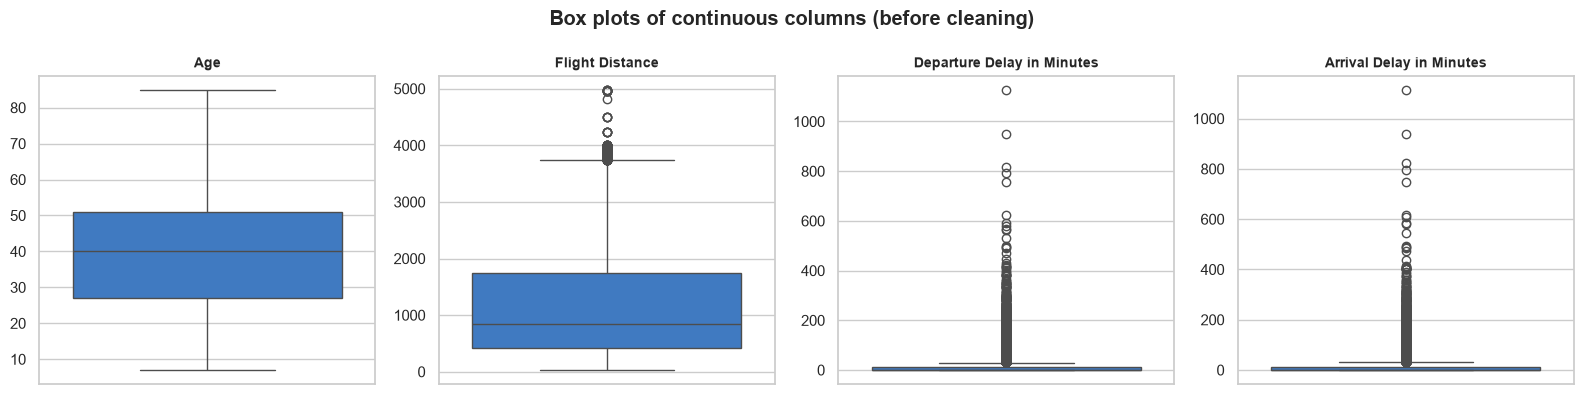

In [9]:
continuous_columns = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for axis, column in zip(axes, continuous_columns):
    sns.boxplot(y=raw_df[column], ax=axis, color=SATISFIED_COLOR, linewidth=1)
    axis.set_title(column, fontsize=10)
    axis.set_ylabel("")
fig.suptitle("Box plots of continuous columns (before cleaning)", fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
def count_iqr_outliers(series):
    """Count values lying outside 1.5 * IQR of a numeric series."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

pd.Series({column: count_iqr_outliers(raw_df[column].dropna()) for column in continuous_columns},
          name="IQR outliers")

Age                              0
Flight Distance                584
Departure Delay in Minutes    3569
Arrival Delay in Minutes      3538
Name: IQR outliers, dtype: int64

In [11]:
# Are the delay outliers real? Departure and arrival delays should move together
delay_corr = raw_df["Departure Delay in Minutes"].corr(raw_df["Arrival Delay in Minutes"])
print(f"Correlation between departure and arrival delay: {delay_corr:.3f}")

Correlation between departure and arrival delay: 0.965


### 4.5 Assessment summary — problems found in the data

**Quality issues**
1. `Arrival Delay in Minutes` has **83 missing values** (0.32 %).
2. `Arrival Delay in Minutes` is stored as **float** although it holds whole minutes.
3. Service ratings contain **0 values that are not real ratings** (0 = "Not Applicable"), e.g. 1,381 in *Departure/Arrival time convenient* and 1,195 in *Ease of Online booking*. Left as 0 they would wrongly drag the averages down.
4. **Inconsistent capitalisation** in labels: `disloyal Customer` vs `Loyal Customer`, `Business travel` vs `Personal Travel`, `neutral or dissatisfied` / `satisfied` in lower case, `Eco` as an abbreviation of *Economy*.
5. **Extreme outliers** in delays (max ≈ 1,128 minutes) and flight distance. The very strong correlation between departure and arrival delays (≈ 0.96) shows they are *genuine* long delays, not typing errors — so they are kept, but capped where needed in plots.
6. Categorical columns are stored as plain text instead of the memory-efficient **category** type.

**Tidiness issues**
7. `Unnamed: 0` is a **useless index column** left over from a previous export.
8. Column names contain **spaces, slashes and mixed case** (e.g. `Departure/Arrival time convenient`), which are awkward to use in code.
9. There is no **age group** or **delay category** column to compare passenger segments easily.

No duplicated rows or duplicated passenger ids were found.

## 5. Data Cleaning

Each issue is handled with the **Define → Code → Test** approach. All changes are made on a copy so the raw data stays untouched.

In [12]:
clean_df = raw_df.copy()

### Issue 7 — Useless index column
**Define:** Drop `Unnamed: 0`; it is only a copy of the row number.

In [13]:
clean_df = clean_df.drop(columns=["Unnamed: 0"])

# Test
assert "Unnamed: 0" not in clean_df.columns
print("Columns now:", clean_df.shape[1])

Columns now: 24


### Issue 8 — Unclear column names
**Define:** Convert every column name to `snake_case` (lower case, words joined by `_`, no slashes) with a reusable function.

In [14]:
def to_snake_case(name):
    """Convert a column name such as 'Departure/Arrival time convenient' to 'departure_arrival_time_convenient'."""
    return (name.strip().lower()
            .replace("/", " ").replace("-", " ")
            .replace(" in minutes", "")
            .replace(" ", "_"))

clean_df.columns = [to_snake_case(column) for column in clean_df.columns]

# Test
print(clean_df.columns.tolist())

['id', 'gender', 'customer_type', 'age', 'type_of_travel', 'class', 'flight_distance', 'inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on_board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness', 'departure_delay', 'arrival_delay', 'satisfaction']


In [15]:
# Keep the cleaned names of the rating columns for later use
service_columns = list(clean_df.loc[:, "inflight_wifi_service":"cleanliness"].columns)

def pretty_name(column):
    """Turn a snake_case column back into a readable label for charts."""
    return column.replace("_", " ").title()

print(len(service_columns), "service columns:", service_columns)

14 service columns: ['inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on_board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness']


### Issue 4 — Inconsistent capitalisation / abbreviations in labels
**Define:** Map every categorical label to one consistent, readable form.

In [16]:
label_mappings = {
    "customer_type": {"Loyal Customer": "Loyal Customer", "disloyal Customer": "Disloyal Customer"},
    "type_of_travel": {"Business travel": "Business Travel", "Personal Travel": "Personal Travel"},
    "class": {"Business": "Business", "Eco": "Economy", "Eco Plus": "Economy Plus"},
    "satisfaction": {"satisfied": "Satisfied", "neutral or dissatisfied": "Neutral or Dissatisfied"},
}

def standardise_labels(df, mappings):
    """Replace labels column by column; raise an error if any label was not covered by the mapping."""
    df = df.copy()
    for column, mapping in mappings.items():
        unmapped = set(df[column].unique()) - set(mapping)
        if unmapped:
            raise ValueError(f"Unmapped labels in {column}: {unmapped}")
        df[column] = df[column].map(mapping)
    return df

clean_df = standardise_labels(clean_df, label_mappings)

# Test
for column in ["gender", "customer_type", "type_of_travel", "class", "satisfaction"]:
    print(f"{column}: {sorted(clean_df[column].unique())}")

gender: ['Female', 'Male']
customer_type: ['Disloyal Customer', 'Loyal Customer']
type_of_travel: ['Business Travel', 'Personal Travel']
class: ['Business', 'Economy', 'Economy Plus']
satisfaction: ['Neutral or Dissatisfied', 'Satisfied']


### Issue 1 & 2 — Missing arrival delays and wrong data type
**Define:** Departure and arrival delays are almost perfectly correlated (r ≈ 0.96), so the best estimate of a missing arrival delay is the **same passenger's departure delay** (more accurate than a global mean or median). After filling, convert the column to integer.

In [17]:
missing_before = clean_df["arrival_delay"].isna().sum()
clean_df["arrival_delay"] = clean_df["arrival_delay"].fillna(clean_df["departure_delay"]).astype(int)

# Test
print(f"Missing arrival delays: {missing_before} → {clean_df['arrival_delay'].isna().sum()}")
print("dtype:", clean_df["arrival_delay"].dtype)

Missing arrival delays: 83 → 0
dtype: int64


### Issue 3 — Rating 0 means "Not Applicable"
**Define:** Replace 0 in the 14 rating columns with `NaN`, so "not applicable" answers are ignored when calculating averages instead of being counted as the worst score. The original zeros are kept as information: we count them per passenger in `not_applicable_count`.

In [18]:
clean_df["not_applicable_count"] = (clean_df[service_columns] == 0).sum(axis=1)
clean_df[service_columns] = clean_df[service_columns].replace(0, np.nan)

# Test
print("Minimum rating now:", clean_df[service_columns].min().min())
print("Maximum rating now:", clean_df[service_columns].max().max())
print("Passengers with at least one N/A answer:", (clean_df["not_applicable_count"] > 0).sum())

Minimum rating now: 1.0
Maximum rating now: 5.0
Passengers with at least one N/A answer: 2113


### Issue 5 — Outliers in delays and flight distance
**Define:** The extreme values are **real** (long delays happen and long-haul flights exist; departure and arrival delays confirm each other), so we **keep them**. To make them easier to analyse we add delay categories instead of deleting data.

### Issue 9 — Missing helper columns (feature engineering)
**Define:** Add columns that make segment comparisons easy:
- `age_group` — Child, Young Adult, Adult, Middle-Aged, Senior
- `distance_group` — Short-haul, Medium-haul, Long-haul
- `delay_group` — based on the arrival delay
- `average_service_rating` — mean of the 14 ratings (N/A ignored)
- `is_satisfied` — 1 for satisfied, 0 otherwise (to compute satisfaction rates easily)

In [19]:
def add_features(df):
    """Add segment and summary columns used in the analysis and the dashboard."""
    df = df.copy()
    df["age_group"] = pd.cut(df["age"], bins=[0, 17, 29, 44, 59, 120],
                             labels=["Child (<18)", "Young Adult (18-29)", "Adult (30-44)",
                                     "Middle-Aged (45-59)", "Senior (60+)"])
    df["distance_group"] = pd.cut(df["flight_distance"], bins=[0, 800, 2000, np.inf],
                                  labels=["Short-haul (<800 mi)", "Medium-haul (800-2000 mi)",
                                          "Long-haul (>2000 mi)"])
    df["delay_group"] = pd.cut(df["arrival_delay"], bins=[-1, 0, 15, 60, np.inf],
                               labels=["On time", "1-15 min", "16-60 min", "> 60 min"])
    df["average_service_rating"] = df[service_columns].mean(axis=1).round(2)
    df["is_satisfied"] = (df["satisfaction"] == "Satisfied").astype(int)
    return df

clean_df = add_features(clean_df)

# Test
clean_df[["age", "age_group", "flight_distance", "distance_group",
          "arrival_delay", "delay_group", "average_service_rating", "is_satisfied"]].head()

,age,age_group,flight_distance,distance_group,arrival_delay,delay_group,average_service_rating,is_satisfied
0,52,Middle-Aged (45-59),160,Short-haul (<800 mi),44,16-60 min,4.14,1
1,36,Adult (30-44),2863,Long-haul (>2000 mi),0,On time,3.43,1
2,20,Young Adult (18-29),192,Short-haul (<800 mi),0,On time,2.31,0
3,44,Adult (30-44),3377,Long-haul (>2000 mi),6,1-15 min,2.27,1
4,49,Middle-Aged (45-59),1182,Medium-haul (800-2000 mi),20,16-60 min,2.64,1


### Issue 6 — Categorical columns stored as text
**Define:** Convert the text columns to the `category` type with a meaningful order.

In [20]:
category_orders = {
    "gender": ["Female", "Male"],
    "customer_type": ["Loyal Customer", "Disloyal Customer"],
    "type_of_travel": ["Business Travel", "Personal Travel"],
    "class": ["Economy", "Economy Plus", "Business"],
    "satisfaction": ["Neutral or Dissatisfied", "Satisfied"],
}
memory_before = clean_df.memory_usage(deep=True).sum() / 1024 ** 2
for column, order in category_orders.items():
    clean_df[column] = pd.Categorical(clean_df[column], categories=order, ordered=(column == "class"))
memory_after = clean_df.memory_usage(deep=True).sum() / 1024 ** 2

# Test
print(clean_df[list(category_orders)].dtypes)
print(f"Memory: {memory_before:.2f} MB → {memory_after:.2f} MB")

gender            category
customer_type     category
type_of_travel    category
class             category
satisfaction      category
dtype: object
Memory: 6.91 MB → 4.56 MB


### 5.1 Final check of the cleaned data

In [21]:
print(f"Shape: {clean_df.shape}")
quality_report(clean_df)

Shape: (25976, 30)


,dtype,missing,missing_%,unique,sample
id,int64,0,0.00,25976,19556
gender,category,0,0.00,2,Female
customer_type,category,0,0.00,2,Loyal Customer
age,int64,0,0.00,75,52
type_of_travel,category,0,0.00,2,Business Travel
class,category,0,0.00,3,Economy
flight_distance,int64,0,0.00,3281,160
inflight_wifi_service,float64,813,3.13,5,5.0
departure_arrival_time_convenient,float64,1381,5.32,5,4.0
ease_of_online_booking,float64,1195,4.60,5,3.0


In [22]:
# Save the cleaned data — it is used by the Streamlit dashboard
clean_df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Cleaned data saved to {CLEAN_DATA_PATH}")

Cleaned data saved to Data_Cleaned.csv


### 5.2 Cleaning log

| # | Problem | Action taken | Result |
|---|---|---|---|
| 1 | 83 missing `Arrival Delay` | Filled with the passenger's departure delay (r ≈ 0.96) | 0 missing |
| 2 | Arrival delay stored as float | Converted to int | Correct type |
| 3 | 0 ratings = "Not Applicable" | Replaced with NaN, counted in `not_applicable_count` | Ratings on a true 1–5 scale |
| 4 | Inconsistent labels | Standardised capitalisation, `Eco` → `Economy` | Consistent labels |
| 5 | Outliers in delays / distance | Verified as genuine and kept; grouped into bins | No data lost |
| 6 | Text columns | Converted to ordered `category` dtype | Less memory, correct order |
| 7 | Useless `Unnamed: 0` column | Dropped | — |
| 8 | Messy column names | Converted to `snake_case` | Easy to use in code |
| 9 | No segment columns | Added age, distance, delay groups, average rating, satisfied flag | Ready for analysis |

> **Note:** the remaining `NaN` values in some rating columns are **intentional** — they are the "Not Applicable" answers and are simply ignored when averages are calculated.


## 6. Exploratory Data Analysis — Univariate Analysis (1D)

We first look at each variable on its own: **satisfaction, gender, customer type, type of travel, class, age, flight distance, delays and the 14 service ratings**.

### 6.1 Satisfaction (target) — answers **Q1**

,passengers,share_%
satisfaction,,
Neutral or Dissatisfied,14573,56.1
Satisfied,11403,43.9


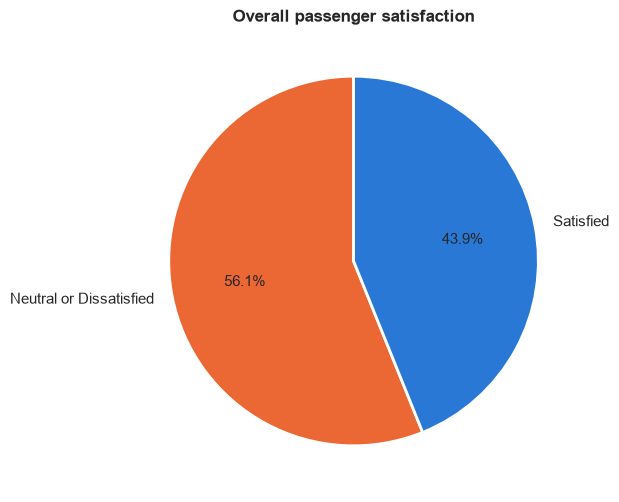

In [23]:
satisfaction_counts = clean_df["satisfaction"].value_counts()
satisfaction_share = clean_df["satisfaction"].value_counts(normalize=True) * 100
display(pd.DataFrame({"passengers": satisfaction_counts, "share_%": satisfaction_share.round(1)}))

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(satisfaction_counts, labels=satisfaction_counts.index, autopct="%1.1f%%", startangle=90,
       colors=[SATISFACTION_PALETTE[label] for label in satisfaction_counts.index],
       wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 11})
ax.set_title("Overall passenger satisfaction")
plt.show()

**Insight (Q1):** Only **43.9 %** of passengers are satisfied; **56.1 %** are neutral or dissatisfied. The majority of passengers are *not* happy, so there is clear room for improvement. The classes are reasonably balanced, so comparisons between the two groups are reliable.

### 6.2 Passenger profile — categorical variables

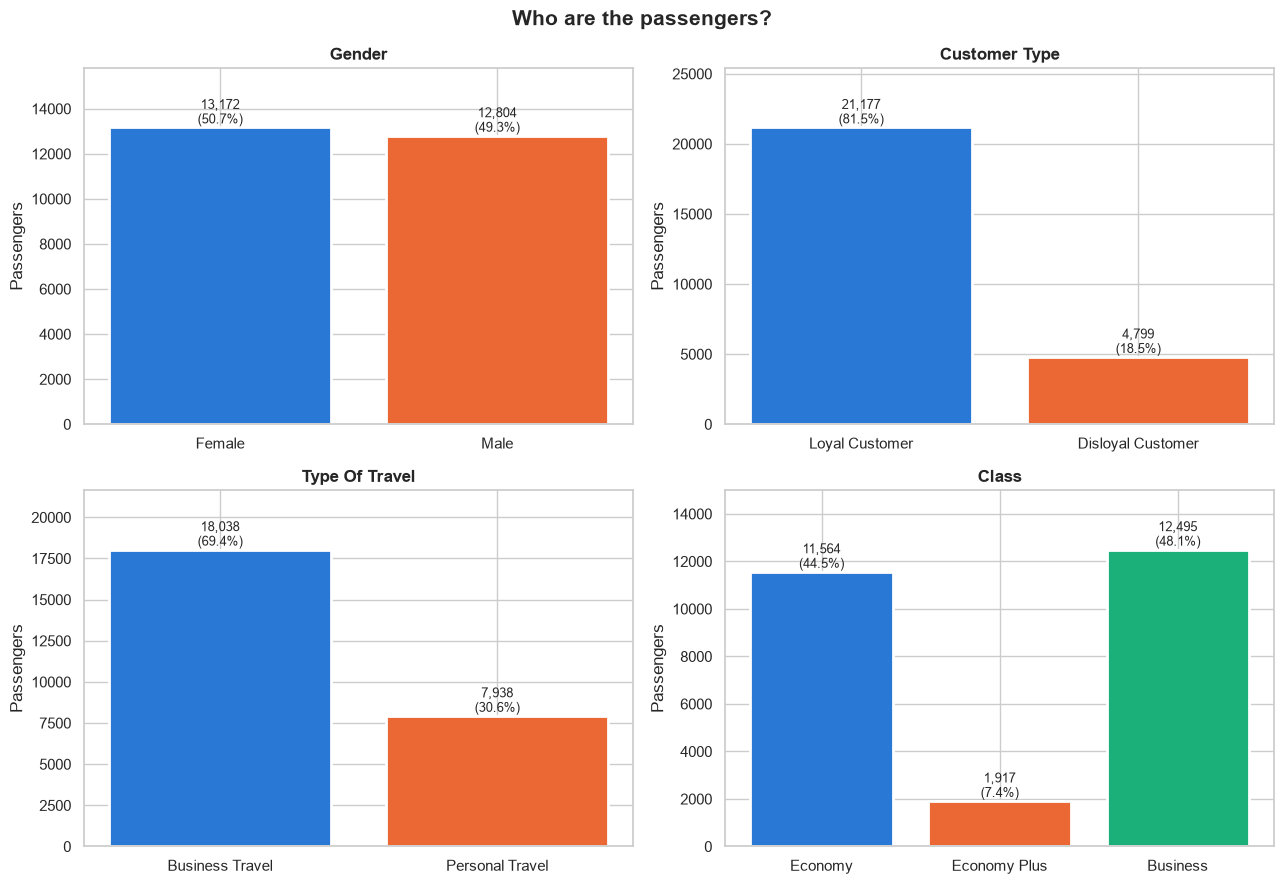

In [24]:
def plot_category_counts(df, column, ax):
    """Bar chart of a categorical column with the percentage written on each bar."""
    counts = df[column].value_counts().reindex(df[column].cat.categories)
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=CATEGORY_COLORS[:len(counts)], edgecolor="white", linewidth=2)
    for bar, value in zip(bars, counts.values):
        ax.annotate(f"{value:,}\n({value / len(df):.1%})", (bar.get_x() + bar.get_width() / 2, value),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(pretty_name(column))
    ax.set_ylabel("Passengers")
    ax.set_ylim(0, counts.max() * 1.2)

profile_columns = ["gender", "customer_type", "type_of_travel", "class"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for column, ax in zip(profile_columns, axes.flat):
    plot_category_counts(clean_df, column, ax)
fig.suptitle("Who are the passengers?", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights:**
- **Gender** is almost perfectly balanced (50.7 % female, 49.3 % male).
- **81.5 %** of passengers are **loyal customers**.
- **69.4 %** travel for **business**, 30.6 % for personal reasons.
- **Business class (48.1 %)** and **Economy (44.5 %)** dominate; **Economy Plus** is small (7.4 %).

### 6.3 Age and flight distance

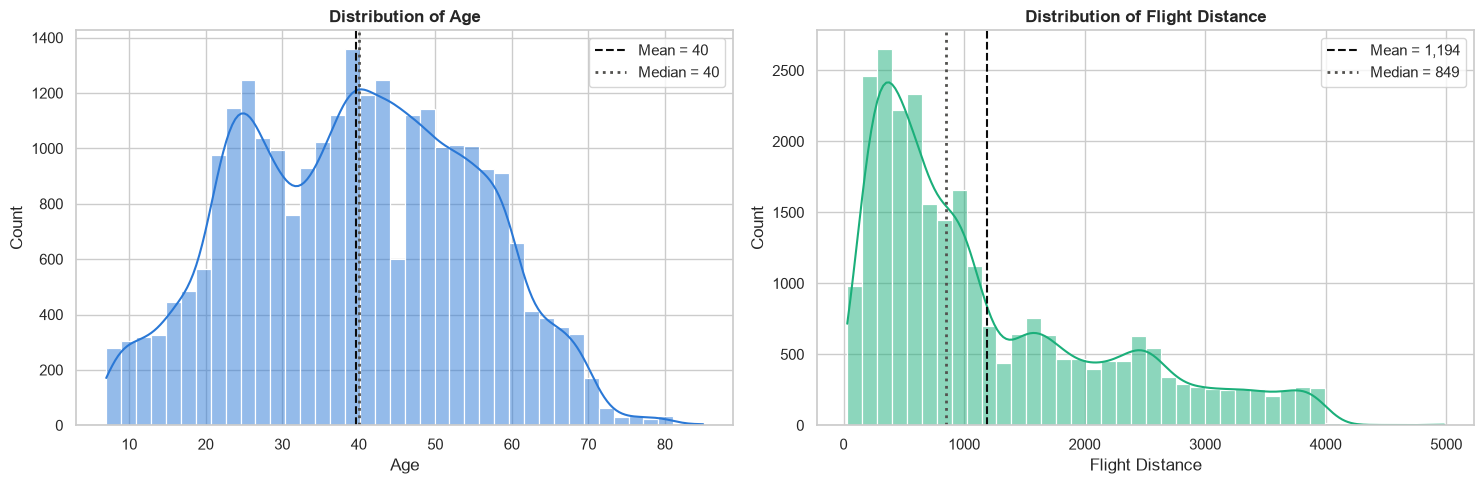

,age,flight_distance
mean,39.62,1193.79
median,40.00,849.00
std,15.14,998.68
min,7.00,31.00
max,85.00,4983.00
skew,-0.00,1.10


In [25]:
def plot_numeric_distribution(df, column, ax, bins=40, color=SATISFIED_COLOR):
    """Histogram with KDE curve plus mean and median reference lines."""
    sns.histplot(df[column], bins=bins, kde=True, color=color, edgecolor="white", ax=ax)
    ax.axvline(df[column].mean(), color="#0b0b0b", linestyle="--", linewidth=1.5,
               label=f"Mean = {df[column].mean():,.0f}")
    ax.axvline(df[column].median(), color="#52514e", linestyle=":", linewidth=2,
               label=f"Median = {df[column].median():,.0f}")
    ax.set_title(f"Distribution of {pretty_name(column)}")
    ax.set_xlabel(pretty_name(column))
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_numeric_distribution(clean_df, "age", axes[0])
plot_numeric_distribution(clean_df, "flight_distance", axes[1], color=CATEGORY_COLORS[2])
plt.tight_layout()
plt.show()

clean_df[["age", "flight_distance"]].agg(["mean", "median", "std", "min", "max", "skew"]).round(2)

**Insights:**
- **Age** ranges from 7 to 85 with a mean of ~40 years; the distribution is roughly symmetric (skew ≈ 0) with two peaks around **25** and **40–45** years; half of the passengers are between 27 and 51.
- **Flight distance** is strongly **right-skewed** (median 849 mi < mean 1,194 mi): most flights are short-haul, with a long tail of long-haul flights up to ~5,000 mi.

### 6.4 Departure and arrival delays

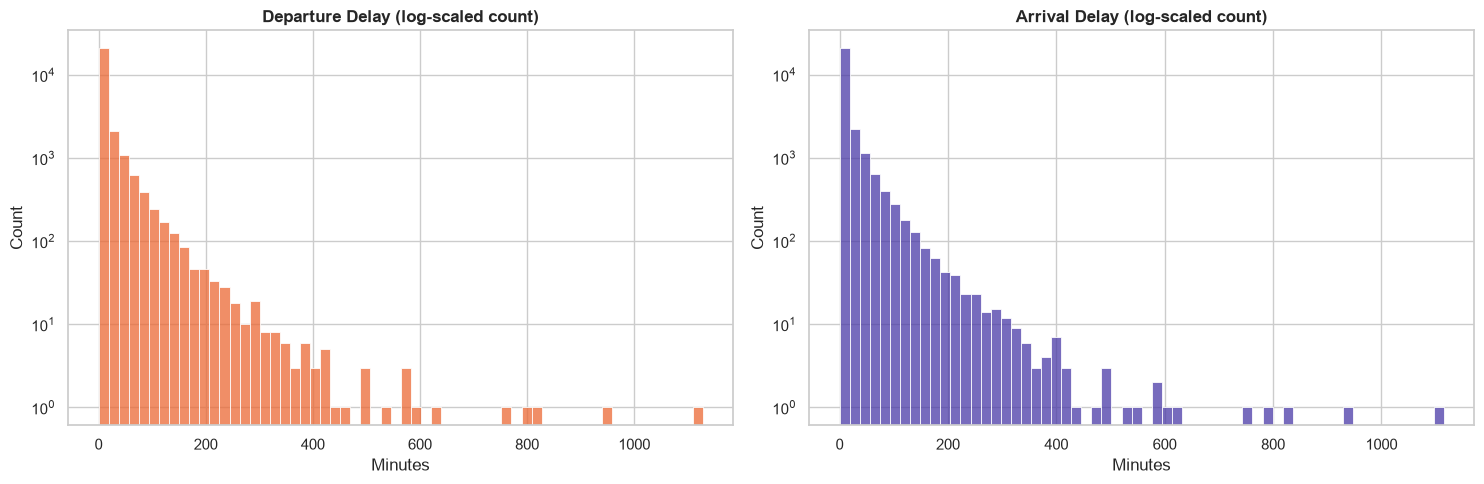

In [26]:
delay_columns = ["departure_delay", "arrival_delay"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, color in zip(axes, delay_columns, [CATEGORY_COLORS[1], CATEGORY_COLORS[6]]):
    sns.histplot(clean_df[column], bins=60, color=color, edgecolor="white", ax=ax)
    ax.set_yscale("log")   # log scale: most values are 0, a few are very large
    ax.set_title(f"{pretty_name(column)} (log-scaled count)")
    ax.set_xlabel("Minutes")
plt.tight_layout()
plt.show()

In [27]:
on_time_share = (clean_df[delay_columns] == 0).mean() * 100
print("Share of flights with 0 minutes of delay:")
print(on_time_share.round(1).to_string())
print("\nArrival delay groups (%):")
print((clean_df["delay_group"].value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Share of flights with 0 minutes of delay:
departure_delay    56.5
arrival_delay      56.3

Arrival delay groups (%):
delay_group
On time      56.3
1-15 min     20.8
16-60 min    16.1
> 60 min      6.8


**Insights:** More than half of the flights arrive **on time** (56.3 %). Delays are extremely skewed: most delays are short, but 6.8 % of passengers arrived more than an hour late, with extremes of over 18 hours.

### 6.5 Service ratings

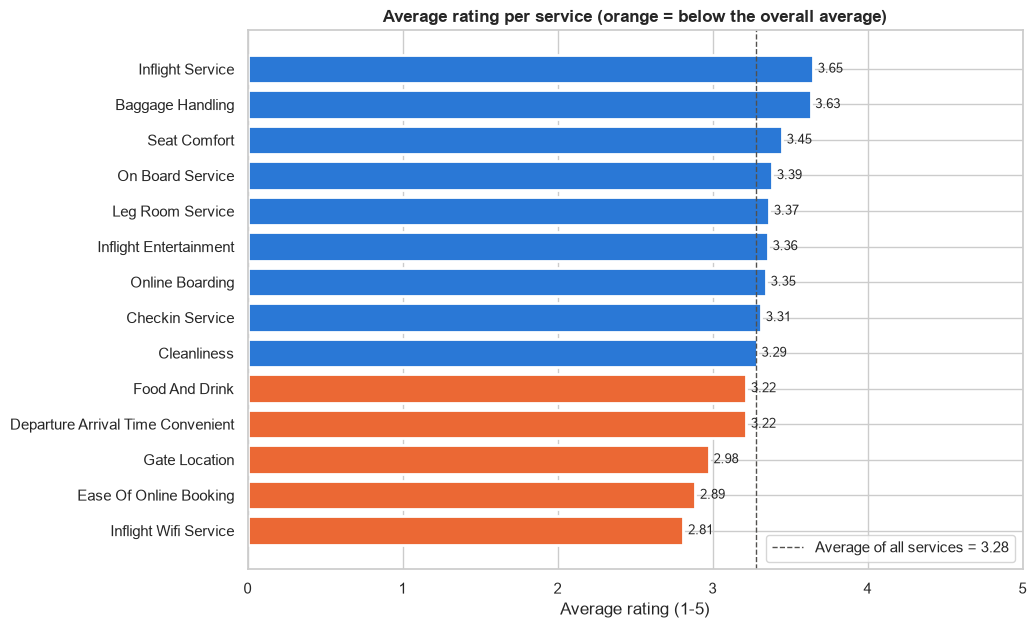

In [28]:
average_ratings = clean_df[service_columns].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [DISSATISFIED_COLOR if value < average_ratings.mean() else SATISFIED_COLOR for value in average_ratings]
ax.barh([pretty_name(c) for c in average_ratings.index], average_ratings.values,
        color=bar_colors, edgecolor="white", linewidth=2)
for y, value in enumerate(average_ratings.values):
    ax.text(value + 0.03, y, f"{value:.2f}", va="center", fontsize=9)
ax.axvline(average_ratings.mean(), color="#52514e", linestyle="--", linewidth=1,
           label=f"Average of all services = {average_ratings.mean():.2f}")
ax.set_xlim(0, 5)
ax.set_xlabel("Average rating (1-5)")
ax.set_title("Average rating per service (orange = below the overall average)")
ax.legend(loc="lower right")
plt.show()

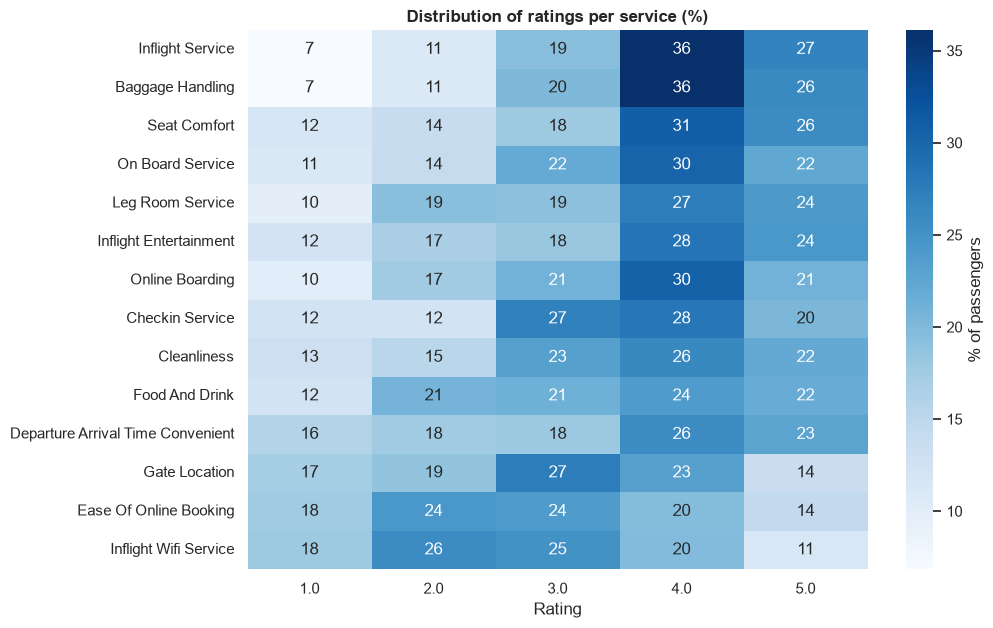

In [29]:
# Share of each rating (1-5) per service — a heatmap of the full distributions
rating_distribution = (clean_df[service_columns]
                       .apply(lambda column: column.value_counts(normalize=True))
                       .T.mul(100).loc[average_ratings.index[::-1]])
rating_distribution.index = [pretty_name(c) for c in rating_distribution.index]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(rating_distribution, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of passengers"}, ax=ax)
ax.set_xlabel("Rating")
ax.set_title("Distribution of ratings per service (%)")
plt.show()

**Insights:**
- Five services are **below the overall average (3.28)**. The **weakest** are **Inflight wifi (2.81)**, **Ease of online booking (2.89)** and **Gate location (2.98)** — the digital experience is the airline's weakest point.
- The **best rated** services are **Inflight service (3.65)** and **Baggage handling (3.63)**.
- No service reaches an average of 4/5, so every touch-point has potential for improvement.

### 6.6 Univariate summary
| Variable | Key finding |
|---|---|
| Satisfaction | 56 % neutral/dissatisfied vs 44 % satisfied |
| Gender | Balanced |
| Customer type | 82 % loyal |
| Type of travel | 69 % business travel |
| Class | Business 48 %, Economy 45 %, Economy Plus 7 % |
| Age | Symmetric, mean ≈ 40 |
| Flight distance | Right-skewed, median 849 mi |
| Delays | 56 % on time, long right tail |
| Services | Wifi and online booking rated lowest |

## 7. Exploratory Data Analysis — Bivariate & Multivariate Analysis

Now we relate each variable to **satisfaction** (and to each other) to answer questions Q2–Q6. Every visual finding is backed by a **statistical test**:
- **Chi-square test + Cramér's V** for categorical vs. satisfaction (V: 0.1 = weak, 0.3 = moderate, 0.5 = strong association).
- **Mann-Whitney U test** for numerical vs. satisfaction (the numeric columns are skewed, so a non-parametric test is used).
- **Spearman correlation** for ordinal ratings.

A p-value below **0.05** means the difference is statistically significant.

In [30]:
def chi_square_test(df, column, target="satisfaction"):
    """Chi-square test of independence + Cramér's V effect size between a categorical column and the target."""
    table = pd.crosstab(df[column], df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return {"variable": column, "chi2": round(chi2, 1), "p_value": p_value, "cramers_v": round(cramers_v, 3)}

def mann_whitney_test(df, column, target="satisfaction"):
    """Mann-Whitney U test comparing a numeric column between satisfied and dissatisfied passengers."""
    satisfied = df.loc[df[target] == "Satisfied", column].dropna()
    dissatisfied = df.loc[df[target] == "Neutral or Dissatisfied", column].dropna()
    u_stat, p_value = stats.mannwhitneyu(satisfied, dissatisfied)
    return {"variable": column, "median_satisfied": satisfied.median(),
            "median_dissatisfied": dissatisfied.median(), "p_value": p_value}

def satisfaction_rate(df, columns):
    """Satisfaction rate (%) and passenger count for every group of the given column(s)."""
    return (df.groupby(columns, observed=True)["is_satisfied"]
              .agg(satisfaction_rate="mean", passengers="count")
              .assign(satisfaction_rate=lambda t: (t["satisfaction_rate"] * 100).round(1)))

def plot_satisfaction_split(df, column, ax):
    """100 % stacked bar: share of satisfied vs dissatisfied passengers in each group of a column."""
    shares = pd.crosstab(df[column], df["satisfaction"], normalize="index") * 100
    shares = shares[["Satisfied", "Neutral or Dissatisfied"]]
    shares.plot(kind="bar", stacked=True, ax=ax, width=0.7, edgecolor="white", linewidth=2,
                color=[SATISFIED_COLOR, DISSATISFIED_COLOR], legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f%%", label_type="center", color="white", fontsize=9, fontweight="bold")
    ax.set_title(f"Satisfaction by {pretty_name(column)}")
    ax.set_xlabel("")
    ax.set_ylabel("% of passengers")
    ax.tick_params(axis="x", rotation=0)

### 7.1 Q2 — How does satisfaction differ across passenger segments?

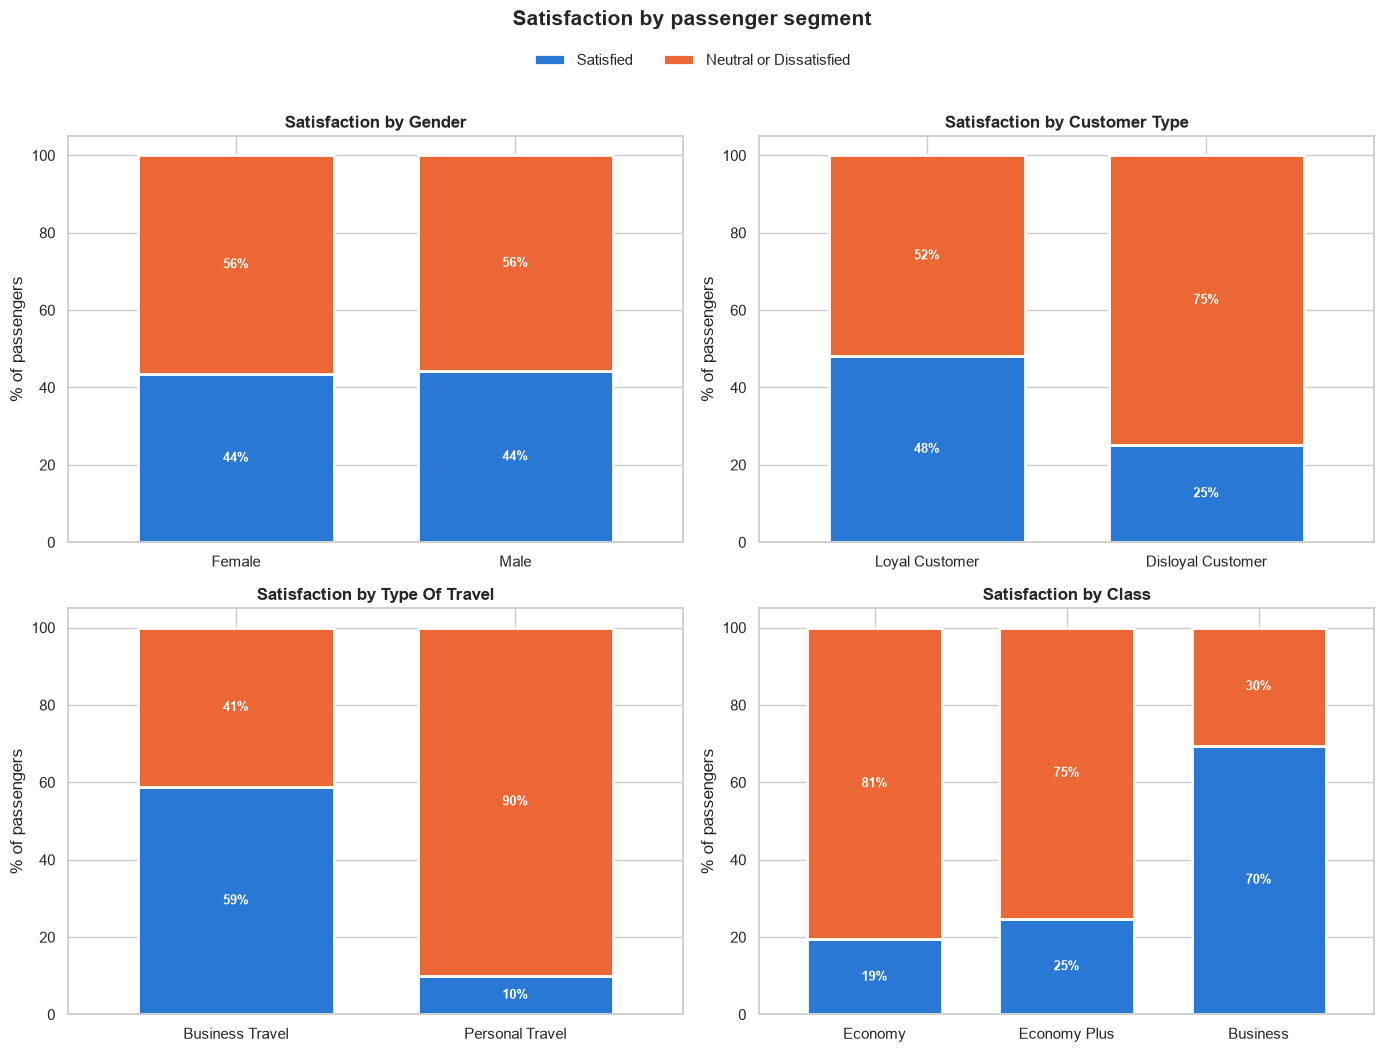

In [31]:
segment_columns = ["gender", "customer_type", "type_of_travel", "class"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for column, ax in zip(segment_columns, axes.flat):
    plot_satisfaction_split(clean_df, column, ax)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Satisfaction by passenger segment", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [32]:
segment_tests = pd.DataFrame([chi_square_test(clean_df, column)
                              for column in segment_columns + ["age_group", "distance_group", "delay_group"]])
segment_tests["significant"] = segment_tests["p_value"] < 0.05
segment_tests.sort_values("cramers_v", ascending=False)

,variable,chi2,p_value,cramers_v,significant
3,class,6435.0,0.000000e+00,0.498,True
2,type_of_travel,5334.8,0.000000e+00,0.453,True
5,distance_group,2059.9,0.000000e+00,0.282,True
4,age_group,1603.2,0.000000e+00,0.248,True
1,customer_type,837.3,4.297553e-184,0.180,True
6,delay_group,236.9,4.377623e-51,0.096,True
0,gender,1.4,2.421285e-01,0.007,False


**Insights (Q2):**
- **Class** (Cramér's V ≈ 0.50) and **Type of travel** (V ≈ 0.45) are by far the strongest drivers: **69.5 %** of Business-class passengers are satisfied vs only **19.4 %** in Economy; **58.8 %** of business travellers are satisfied vs only **10.0 %** of personal travellers.
- **Loyal customers** are almost twice as satisfied (48.1 %) as **disloyal** ones (25.2 %).
- **Gender makes no difference** (43.5 % vs 44.3 %, p = 0.24 → not significant).

#### Age and satisfaction

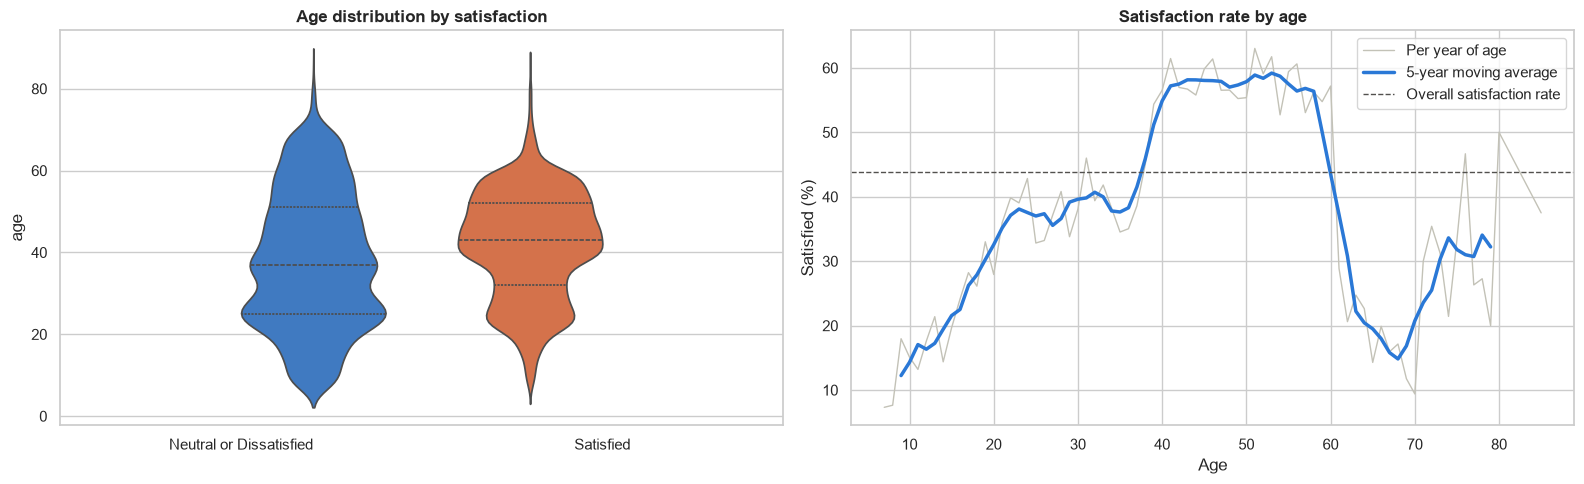

,satisfaction_rate,passengers
age_group,,
Child (<18),18.1,1916
Young Adult (18-29),36.0,5716
Adult (30-44),47.7,8121
Middle-Aged (45-59),57.7,7727
Senior (60+),26.8,2496


{'variable': 'age',
 'median_satisfied': np.float64(43.0),
 'median_dissatisfied': np.float64(37.0),
 'p_value': np.float64(6.600710626409929e-98)}

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(data=clean_df, x="satisfaction", y="age", hue="satisfaction", palette=SATISFACTION_PALETTE,
               inner="quartile", ax=axes[0], legend=False)
axes[0].set_title("Age distribution by satisfaction")
axes[0].set_xlabel("")

age_rate = clean_df.groupby("age")["is_satisfied"].mean().mul(100)
axes[1].plot(age_rate.index, age_rate.values, color="#c3c2b7", linewidth=1, label="Per year of age")
axes[1].plot(age_rate.index, age_rate.rolling(5, center=True).mean(), color=SATISFIED_COLOR, linewidth=2.5,
             label="5-year moving average")
axes[1].axhline(clean_df["is_satisfied"].mean() * 100, color="#52514e", linestyle="--", linewidth=1,
                label="Overall satisfaction rate")
axes[1].set_title("Satisfaction rate by age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Satisfied (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

display(satisfaction_rate(clean_df, "age_group"))
mann_whitney_test(clean_df, "age")

**Insight:** Satisfied passengers are older (median **43** vs **37** years, Mann-Whitney p < 0.001). Satisfaction peaks among **middle-aged passengers (45–59: 57.7 %)** and is lowest for **children (18.1 %)**, **young adults (36.0 %)** and **seniors (26.8 %)** — groups that mostly travel for personal reasons and in Economy.

### 7.2 Q3 — Which services matter most for satisfaction?

In [34]:
service_means = clean_df.groupby("satisfaction", observed=True)[service_columns].mean().T
service_means["gap"] = service_means["Satisfied"] - service_means["Neutral or Dissatisfied"]
service_means["spearman_r"] = [clean_df[c].corr(clean_df["is_satisfied"], method="spearman") for c in service_columns]
service_means = service_means.sort_values("gap")
service_means.round(2)

satisfaction,Neutral or Dissatisfied,Satisfied,gap,spearman_r
departure_arrival_time_convenient,3.29,3.12,-0.17,-0.06
gate_location,3.00,2.95,-0.04,-0.02
food_and_drink,2.96,3.54,0.58,0.21
inflight_service,3.39,3.98,0.58,0.27
baggage_handling,3.37,3.97,0.60,0.28
ease_of_online_booking,2.63,3.24,0.61,0.22
checkin_service,3.04,3.66,0.62,0.24
leg_room_service,3.01,3.83,0.82,0.31
on_board_service,3.02,3.85,0.83,0.33
cleanliness,2.92,3.76,0.84,0.31


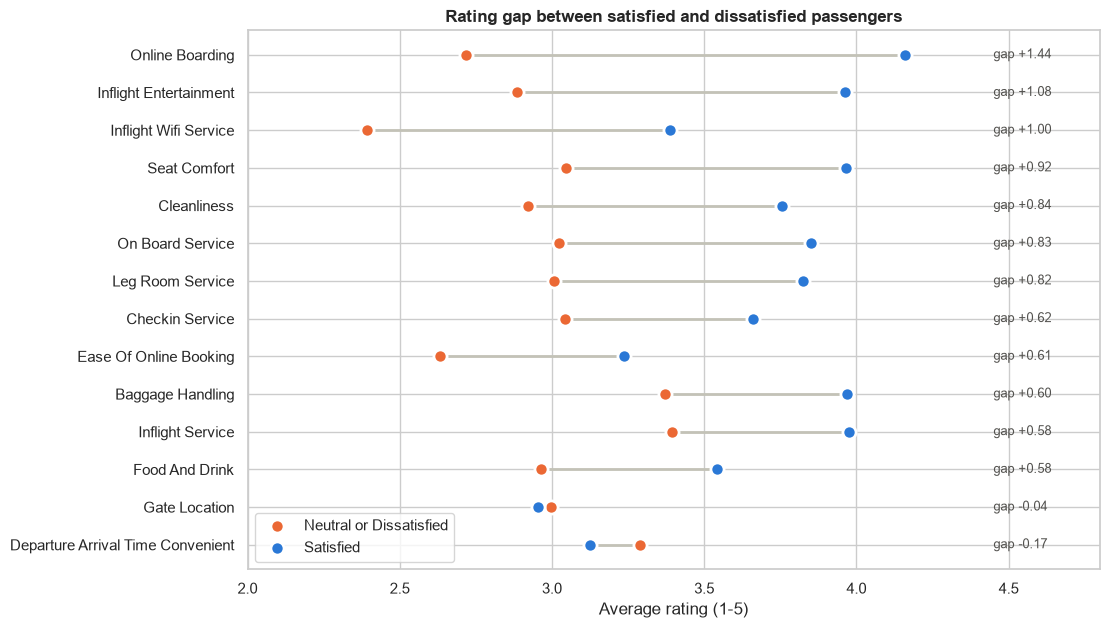

In [35]:
fig, ax = plt.subplots(figsize=(11, 7))
y_positions = np.arange(len(service_means))
ax.hlines(y_positions, service_means["Neutral or Dissatisfied"], service_means["Satisfied"], color="#c3c2b7", linewidth=2)
ax.scatter(service_means["Neutral or Dissatisfied"], y_positions, color=DISSATISFIED_COLOR, s=90,
           label="Neutral or Dissatisfied", zorder=3, edgecolor="white", linewidth=2)
ax.scatter(service_means["Satisfied"], y_positions, color=SATISFIED_COLOR, s=90,
           label="Satisfied", zorder=3, edgecolor="white", linewidth=2)
for y, gap in zip(y_positions, service_means["gap"]):
    ax.text(4.45, y, f"gap {gap:+.2f}", va="center", fontsize=9, color="#52514e")
ax.set_yticks(y_positions, [pretty_name(c) for c in service_means.index])
ax.set_xlim(2, 4.8)
ax.set_xlabel("Average rating (1-5)")
ax.set_title("Rating gap between satisfied and dissatisfied passengers")
ax.legend(loc="lower left")
plt.show()

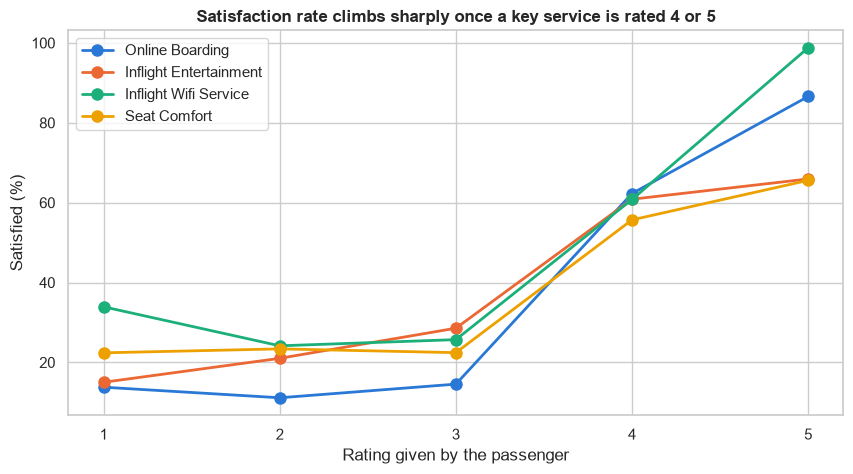

In [36]:
# Satisfaction rate for every rating level of the 4 services with the largest gap
top_services = service_means.index[::-1][:4]
fig, ax = plt.subplots(figsize=(10, 5))
for color, column in zip(CATEGORY_COLORS, top_services):
    rate_by_rating = clean_df.groupby(column)["is_satisfied"].mean() * 100
    ax.plot(rate_by_rating.index, rate_by_rating.values, marker="o", markersize=8, linewidth=2,
            color=color, label=pretty_name(column))
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Rating given by the passenger")
ax.set_ylabel("Satisfied (%)")
ax.set_title("Satisfaction rate climbs sharply once a key service is rated 4 or 5")
ax.legend()
plt.show()

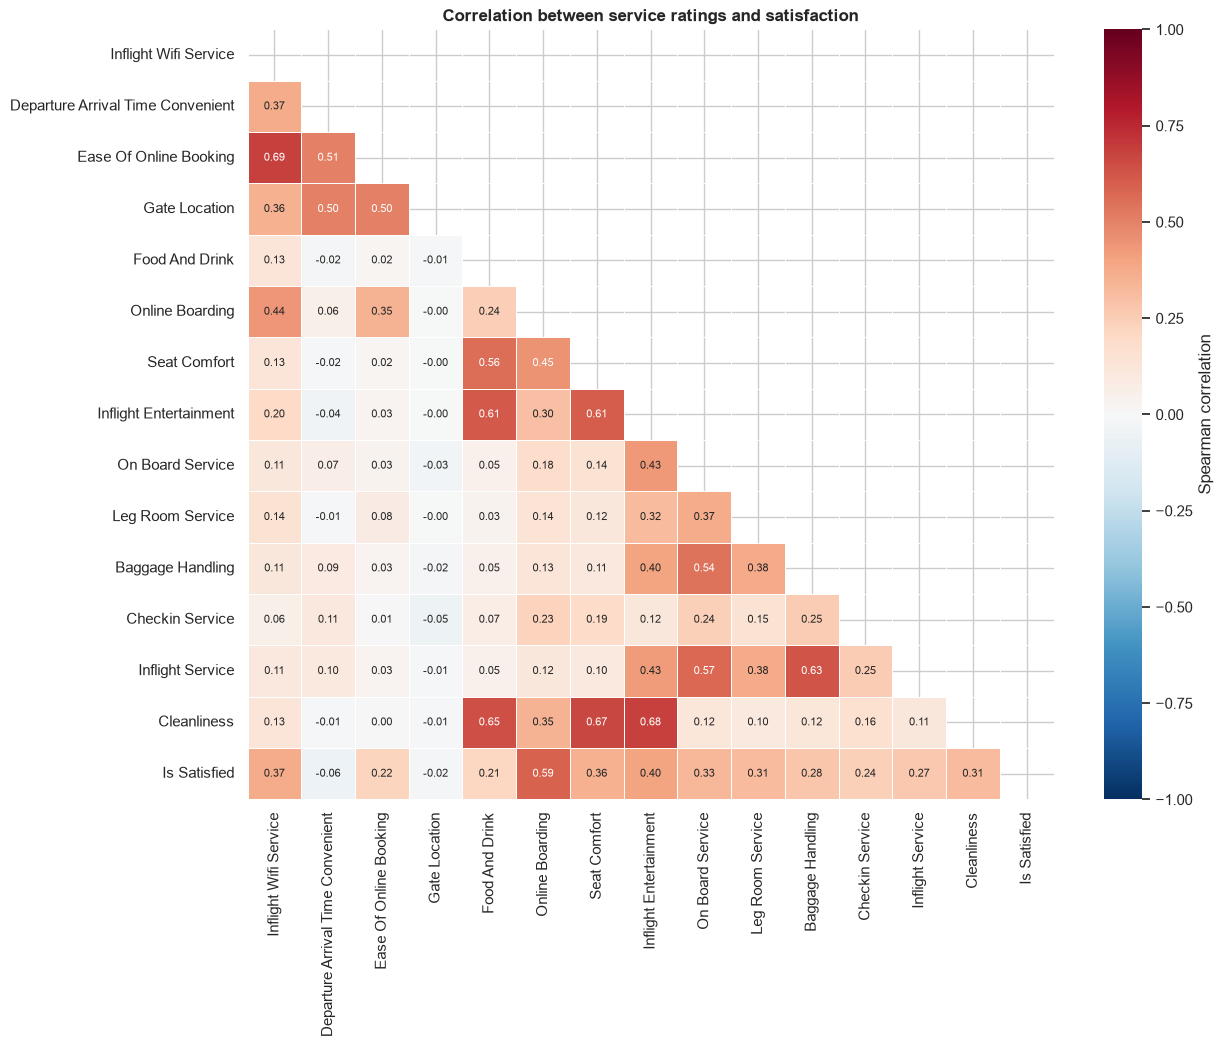

In [37]:
# Correlation between all service ratings (and the satisfied flag)
correlation_matrix = clean_df[service_columns + ["is_satisfied"]].corr(method="spearman")
correlation_matrix.index = correlation_matrix.columns = [pretty_name(c) for c in correlation_matrix.columns]
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Spearman correlation"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation between service ratings and satisfaction")
plt.show()

**Insights (Q3):**
- **Online boarding** is the single most important service: satisfied passengers rate it **1.44 points higher** (4.16 vs 2.72; Spearman r = 0.59). Only ~14 % of passengers who give it 1–3 are satisfied, versus **87 %** of those who give it 5.
- **Inflight entertainment**, **Inflight wifi** and **Seat comfort** follow (gaps of 1.08, 1.00 and 0.92).
- Wifi is critical: passengers rating wifi **5/5** are **98.8 %** satisfied — yet wifi has the **lowest average rating** of all services. This is the biggest opportunity.
- **Gate location** and **Departure/Arrival time convenience** show *no* positive relationship with satisfaction.
- Services form clusters (e.g. *Inflight entertainment ↔ Cleanliness ↔ Seat comfort ↔ Food*, and *Wifi ↔ Ease of online booking*), meaning improvements tend to be perceived together.

### 7.3 Q4 — Do delays reduce satisfaction?

,satisfaction_rate,passengers
delay_group,,
On time,47.9,14625
1-15 min,40.7,5395
16-60 min,37.7,4177
> 60 min,35.2,1779


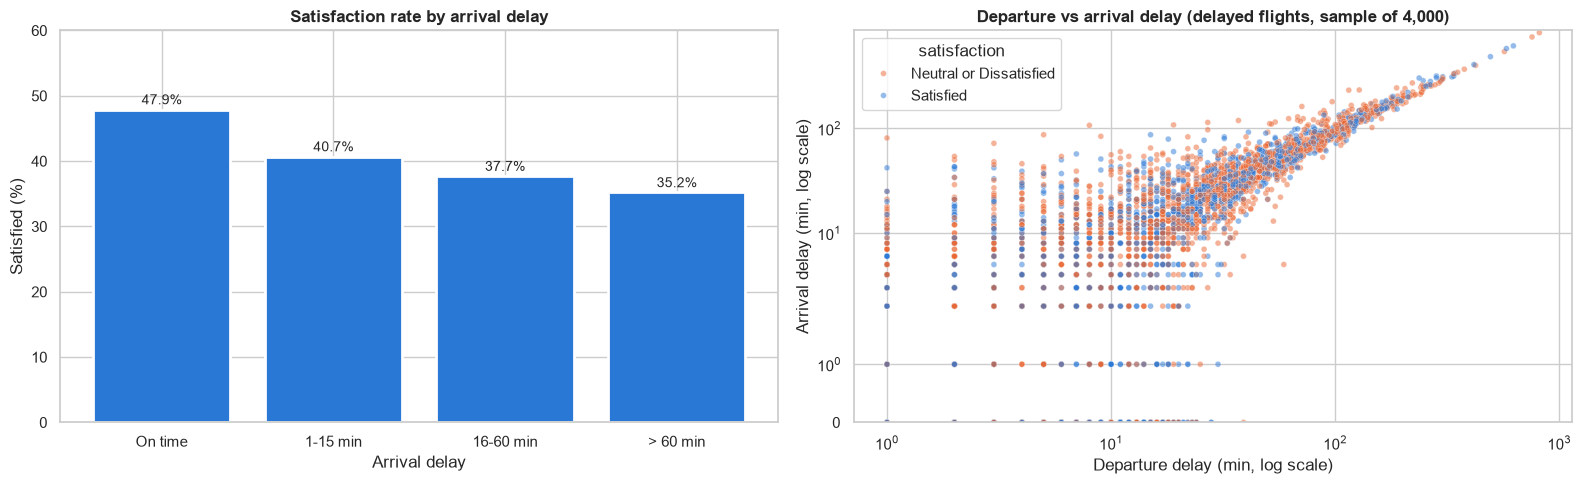

,variable,median_satisfied,median_dissatisfied,p_value
0,departure_delay,0.0,0.0,6.170739e-32
1,arrival_delay,0.0,0.0,2.469452e-58


In [38]:
delay_rates = satisfaction_rate(clean_df, "delay_group")
display(delay_rates)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(delay_rates.index.astype(str), delay_rates["satisfaction_rate"],
            color=SATISFIED_COLOR, edgecolor="white", linewidth=2)
for x, value in enumerate(delay_rates["satisfaction_rate"]):
    axes[0].text(x, value + 0.8, f"{value:.1f}%", ha="center", fontsize=10)
axes[0].set_ylim(0, 60)
axes[0].set_title("Satisfaction rate by arrival delay")
axes[0].set_xlabel("Arrival delay")
axes[0].set_ylabel("Satisfied (%)")

# Scatter of departure vs arrival delay on a random sample, coloured by satisfaction
delay_sample = clean_df[clean_df["departure_delay"] > 0].sample(4000, random_state=42)
sns.scatterplot(data=delay_sample, x="departure_delay", y="arrival_delay", hue="satisfaction",
                palette=SATISFACTION_PALETTE, alpha=0.5, s=18, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("symlog")
axes[1].set_ylim(bottom=0)
axes[1].set_title("Departure vs arrival delay (delayed flights, sample of 4,000)")
axes[1].set_xlabel("Departure delay (min, log scale)")
axes[1].set_ylabel("Arrival delay (min, log scale)")
plt.tight_layout()
plt.show()

pd.DataFrame([mann_whitney_test(clean_df, column) for column in ["departure_delay", "arrival_delay"]])

**Insights (Q4):**
- Satisfaction falls steadily as delays grow: **47.9 %** for on-time arrivals → 40.7 % (1–15 min) → 37.7 % (16–60 min) → **35.2 %** for delays over an hour.
- The difference is statistically significant (Mann-Whitney p < 0.001), but the effect is **weak** (Cramér's V ≈ 0.10) — delays hurt, but much less than class, travel type or service quality.
- Departure and arrival delays move almost perfectly together, confirming the decision to fill missing arrival delays with the departure delay.

### 7.4 Q5 — Does flight distance affect satisfaction, and does it depend on class?

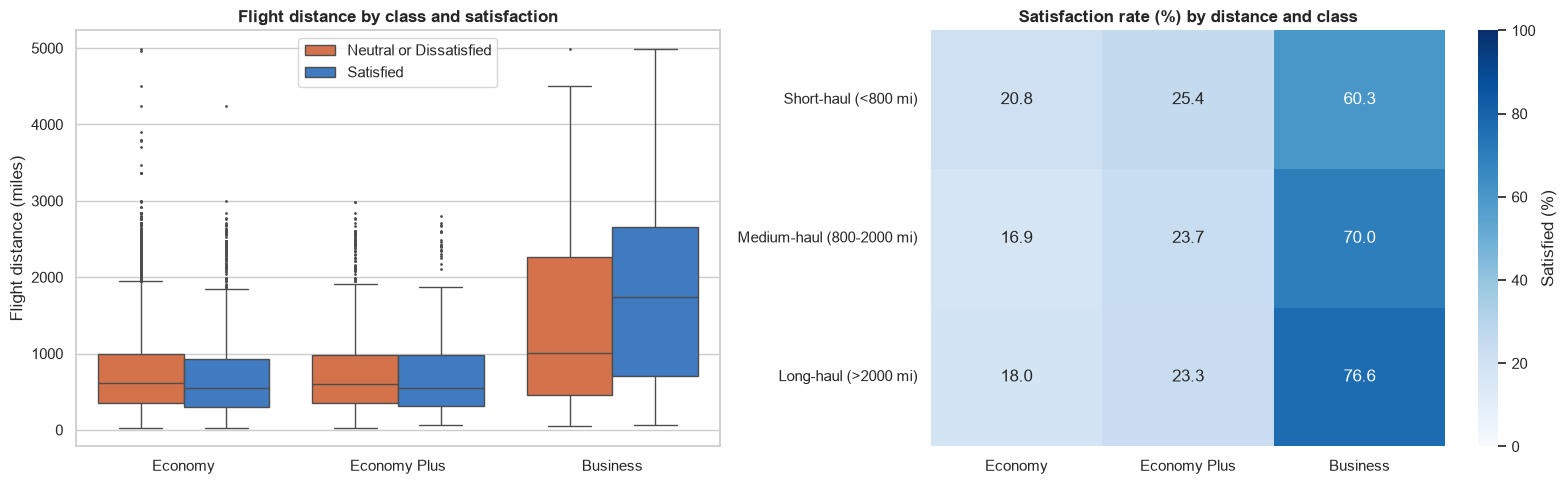

,satisfaction_rate,passengers
distance_group,,
Short-haul (<800 mi),33.7,12436
Medium-haul (800-2000 mi),41.8,8086
Long-haul (>2000 mi),70.1,5454


class
Economy          602.0
Economy Plus     594.0
Business        1590.0
Name: median_distance, dtype: float64

{'variable': 'flight_distance',
 'median_satisfied': np.float64(1237.0),
 'median_dissatisfied': np.float64(679.0),
 'p_value': np.float64(0.0)}

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=clean_df, x="class", y="flight_distance", hue="satisfaction", palette=SATISFACTION_PALETTE,
            linewidth=1, fliersize=1, ax=axes[0])
axes[0].set_title("Flight distance by class and satisfaction")
axes[0].set_xlabel("")
axes[0].set_ylabel("Flight distance (miles)")
axes[0].legend(title="")

distance_class_rate = clean_df.pivot_table(index="distance_group", columns="class", values="is_satisfied",
                                           aggfunc="mean", observed=True) * 100
sns.heatmap(distance_class_rate, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Satisfied (%)"}, ax=axes[1])
axes[1].set_title("Satisfaction rate (%) by distance and class")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

display(satisfaction_rate(clean_df, "distance_group"))
display(clean_df.groupby("class", observed=True)["flight_distance"].median().rename("median_distance"))
mann_whitney_test(clean_df, "flight_distance")

**Insights (Q5):**
- At first sight, distance looks important: **70.1 %** of long-haul passengers are satisfied vs **33.7 %** on short-haul flights (p < 0.001).
- **But this is mostly an effect of class:** long-haul flights are mostly flown in Business class (median Business distance 1,590 mi vs ~600 mi for Economy). **Within the same class, satisfaction barely changes with distance** (Economy: 17–21 % for every distance group).
- Business class gets *better* on longer flights (60.3 % short-haul → **76.6 %** long-haul), probably because its comfort advantages matter more on long trips.

### 7.5 Q6 — Which combination of travel type and class gives the happiest passengers?

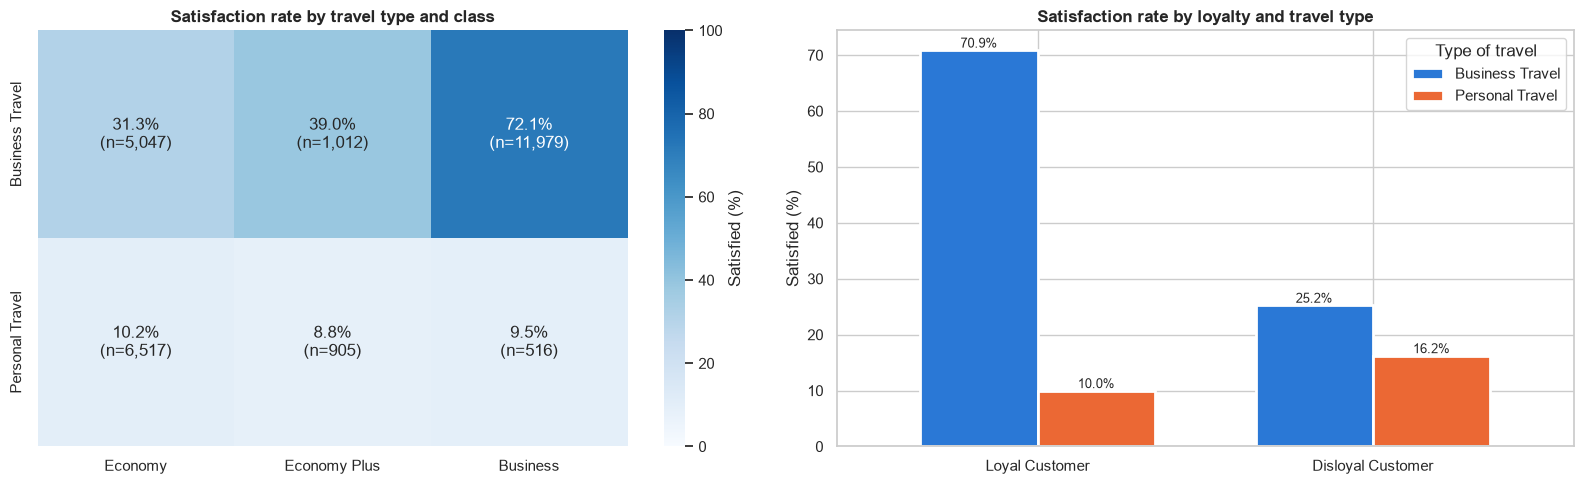

In [40]:
travel_class_rate = clean_df.pivot_table(index="type_of_travel", columns="class", values="is_satisfied",
                                         aggfunc="mean", observed=True) * 100
travel_class_count = clean_df.pivot_table(index="type_of_travel", columns="class", values="id",
                                          aggfunc="count", observed=True)
heatmap_labels = travel_class_rate.round(1).astype(str) + "%\n(n=" + travel_class_count.map("{:,}".format) + ")"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(travel_class_rate, annot=heatmap_labels, fmt="", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Satisfied (%)"}, ax=axes[0])
axes[0].set_title("Satisfaction rate by travel type and class")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

loyalty_travel_rate = (clean_df.groupby(["customer_type", "type_of_travel"], observed=True)["is_satisfied"]
                       .mean().mul(100).unstack())
loyalty_travel_rate.plot(kind="bar", ax=axes[1], color=[CATEGORY_COLORS[0], CATEGORY_COLORS[1]],
                         edgecolor="white", linewidth=2, width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", fontsize=9)
axes[1].set_title("Satisfaction rate by loyalty and travel type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Satisfied (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Type of travel")
plt.tight_layout()
plt.show()

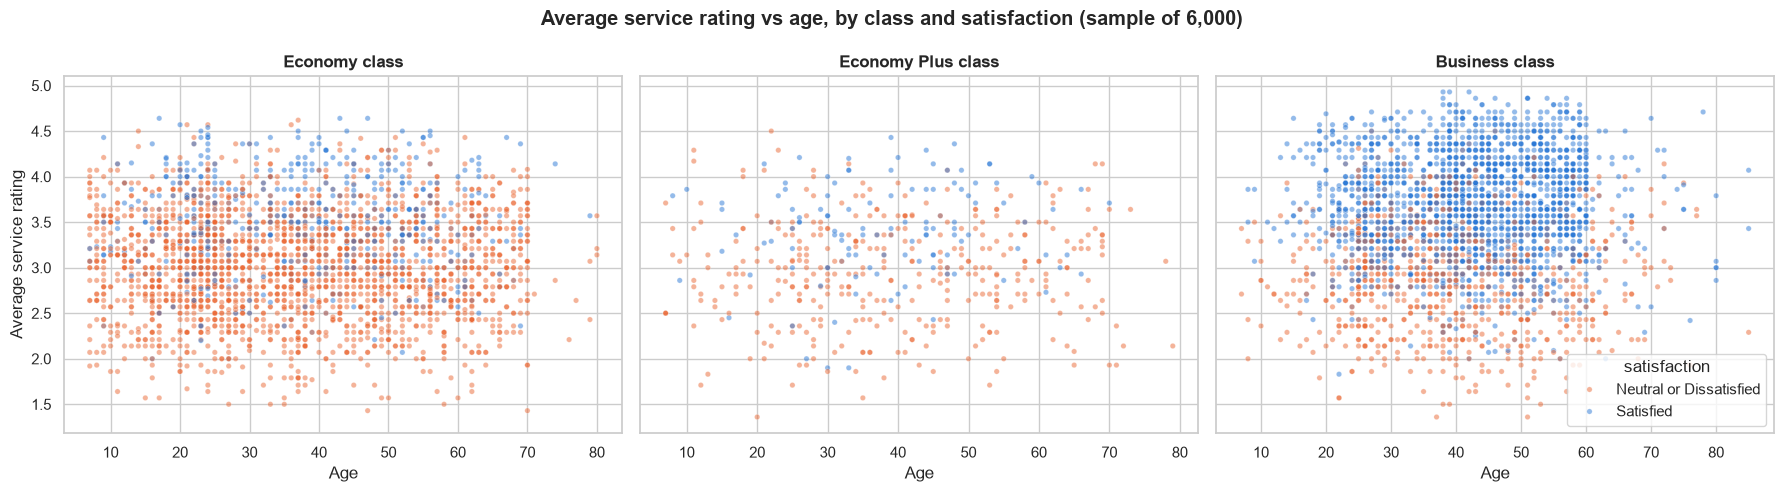

In [41]:
# Multivariate view: average service rating vs age, split by class and satisfaction
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
multivariate_sample = clean_df.sample(6000, random_state=1)
for ax, travel_class in zip(axes, category_orders["class"]):
    subset = multivariate_sample[multivariate_sample["class"] == travel_class]
    sns.scatterplot(data=subset, x="age", y="average_service_rating", hue="satisfaction",
                    palette=SATISFACTION_PALETTE, alpha=0.5, s=15, ax=ax, legend=(travel_class == "Business"))
    ax.set_title(f"{travel_class} class")
    ax.set_xlabel("Age")
axes[0].set_ylabel("Average service rating")
plt.suptitle("Average service rating vs age, by class and satisfaction (sample of 6,000)", fontweight="bold")
plt.tight_layout()
plt.show()

**Insights (Q6):**
- The **happiest** group is **business travellers in Business class: 72.1 %** satisfied (the airline's core customers, n = 11,979).
- The **unhappiest** groups are **personal travellers — whatever their class (≈ 9–10 %)**. Even in Business class, only 9.5 % of personal travellers are satisfied.
- **Loyal business travellers** are satisfied in **70.9 %** of cases, but **loyal personal travellers only 10.0 %** — loyalty alone does not create satisfaction.
- In every class, satisfied passengers sit clearly higher on the average service rating axis, showing that **service quality separates the two groups regardless of age and class**.